# Homework 10


**Concepts covered:**

pandas `DataFrame`s: initialization,  descriptive statistics, line plot, scatter plot, histogram, column-wise operations, row-wise operations.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

While we encourage you to use AI to generate practice problems, **we recommend against using generative AI in the strongest terms** to solve any part of this assignment. The goal of this assignment is for you to learn these concepts, and while using AI may help you obtain solutions to these problems, you will cheat yourself out of the learning that comes from working through the problems yourself.

**Sample Output:**

For each problem description, a sample output has been included to show what the expected output should be.
Some functions have test cases provided for you to test with, so no sample output has been included for those.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [137]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.close("all")

# access to data file(s); update to week-10
df_stock_prices = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/SPY.csv")
df_stock_prices.index = pd.to_datetime(df_stock_prices["date"], unit='s')

df_weather = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/02215_weather.csv")
df_weather.index = pd.to_datetime(df_weather["datetime"], format="%m/%d/%y")


df_econ_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-10/annual_data.csv")
df_econ_data.index = df_econ_data["Year"]



**Note: This will be partially manually graded, so please allow some time before getting your full grade.**

**Review Problem 1**

**Concept:** *matplotlib, scatter plot*


**Task:**

Create a scatter plot that produces a spiral/cyclone pattern.

* Generate radius values that gradually increase
* Generate angle values that rotate around the origin
* Compute:
  * x = radius × cos(angle)
  * y = radius × sin(angle)
* Plot the points using plt.scatter()
* Add a title

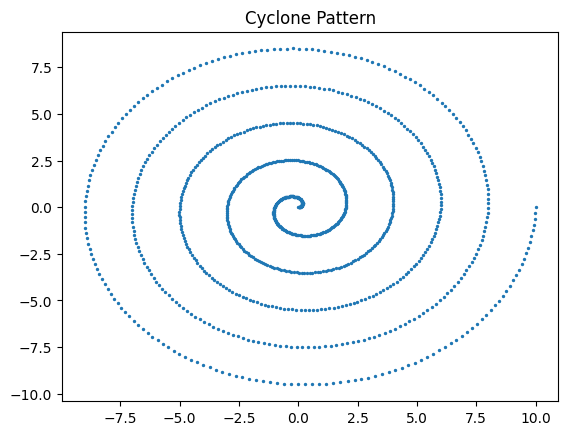

In [138]:
# Your Solution
angles = np.linspace(0, 10 * np.pi, 1000) #create an array of angles from 0 to 10*pi with 1000 points
radius = np.linspace(0, 10, 1000) #create an array of radius values from 0 to 10 with 1000 points

x = radius * np.cos(angles) 
y = radius * np.sin(angles)

plt.scatter(x, y, s=2)
plt.title("Cyclone Pattern")
plt.show()


**Review Problem 2**

**Concept:** *reading CSV data, matplotlib, line graph*

**Task:**

Write a function `read_and_plot_column(filename, column_name)` that:
* Opens a CSV file (do **not** use pandas)
* Extracts the values from the specified column
* Casts all values to `float`
* Plots the values using `plt.plot()`
* Adds a title
* Displays the plot

In [139]:
# Your Solution

def read_and_plot_column(filename, column_name):
    '''Read CSV via pandas and plot a column'''

    df = pd.read_csv(filename) # Read CSV using pandas (no csv module)
    
    values = pd.to_numeric(df[column_name], errors='coerce').dropna() # Convert column to numeric, coercing errors to NaN, then drop NaN values
    

    plt.plot(values)
    plt.title(column_name)
    plt.show()



Test case for problem 2

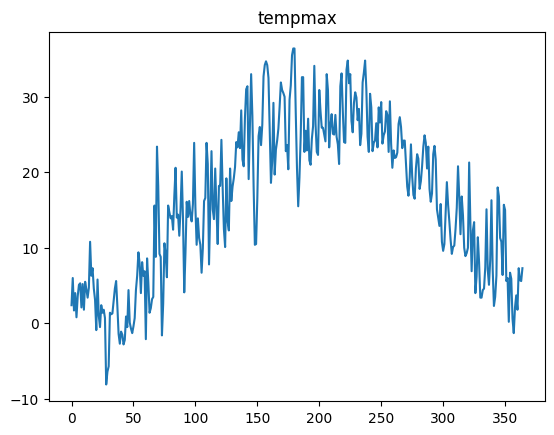

In [140]:
# test case:

read_and_plot_column("02215_weather.csv", "tempmax")




**Problem 3**

**Concept:** *Examining Data*


**Task:**

Using `df_weather`:
* Print the first 5 rows
* Print the last 5 rows

**Important:**

Store your results in the variables below and print them. The autograder will check for these variables.
* `df_weather_head`
* `df_weather_tail`

**Sample Output:**

If the following was your dataframe:

```
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50

```

The following will be your output:

```
FIRST 5 ROWS:
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50

LAST 5 ROWS:
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```


In [141]:
# Your Solution

df_weather_head = df_weather.head() #first 5 rows
df_weather_tail = df_weather.tail() #last 5 rows

print("FIRST 5 ROWS:")
print(df_weather_head)

print("\nLAST 5 ROWS:")
print(df_weather_tail)

FIRST 5 ROWS:
           datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
datetime                                                                  
2021-01-01   1/1/21      2.4     -2.4   0.5           2.3          -6.8   
2021-01-02   1/2/21      6.0      0.1   3.9           3.8          -5.1   
2021-01-03   1/3/21      1.7     -1.4   0.1          -1.7          -5.7   
2021-01-04   1/4/21      4.0     -0.6   1.0          -0.3          -5.7   
2021-01-05   1/5/21      0.8     -1.0  -0.3          -3.9          -6.1   

            feelslike  dew  humidity  precip  ...  solarenergy  uvindex  \
datetime                                      ...                         
2021-01-01       -1.9 -5.4      65.0   0.897  ...          4.8        3   
2021-01-02       -0.4  1.6      85.7  12.092  ...          2.4        1   
2021-01-03       -3.8 -3.0      79.7   0.794  ...          1.5        1   
2021-01-04       -3.5 -2.3      78.9   0.000  ...          4.3        3   
2021-01-05

**Problem 4**

**Concept:** *Accessing `DataFrame` columns*


**Task:**

Using `df_weather`:
* Print all column names
* Create a list of columns that contain the substring `"temp"`
* Create a new DataFrame using only those columns
* Print the result

**Important:**

Store your result in the variable below and print it. The autograder will check for this variable.
* `df_weather_temp_cols`

**Sample Output:**

If the following were your column names and dataframe:
```
Index(['product', 'color', 'price'], dtype='object')

   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```

And you selected the columns that matched your condition, the following could be your output:
```
Index(['product', 'color', 'price'], dtype='object')

   product  color
P1   shirt   blue
P2   pants  black
P3     hat    red
P4  jacket  green
P5   shoes  white
```



In [142]:
# Your Solution

print(df_weather.columns) #print all column names

temp_columns = [col for col in df_weather.columns if "temp" in col] #filter for temp with list comprehension

df_weather_temp_cols = df_weather[temp_columns] #create new dataframe with only temp columns

print(df_weather_temp_cols)

Index(['datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations'],
      dtype='str')
            tempmax  tempmin  temp
datetime                          
2021-01-01      2.4     -2.4   0.5
2021-01-02      6.0      0.1   3.9
2021-01-03      1.7     -1.4   0.1
2021-01-04      4.0     -0.6   1.0
2021-01-05      0.8     -1.0  -0.3
...             ...      ...   ...
2021-12-27      1.8     -1.1   0.5
2021-12-28      7.3      0.6   3.8
2021-12-29      5.7      2.5   4.3
2021-12-30      5.6      3.3   4.6
2021-12-31      7.3      4.4   6.0

[365 rows x 3 columns]


**Problem 5**

**Concept:** *Descriptive Statistics*


**Task:**

Using `df_weather`:

* Display descriptive statistics for all columns

**Important:**

Store your result in the variable below and print it. The autograder will check for this variable.
* `df_weather_descriptive_statistics`

**Sample Output:**

If the following was your dataframe:
```
   product  color  price
P1   shirt   blue     20
P2   pants  black     35
P3     hat    red     15
P4  jacket  green     60
P5   shoes  white     50
```
The following will be your output:
```
DESCRIPTIVE STATISTICS:
           price
count   5.000000
mean   36.000000
std    19.235384
min    15.000000
25%    20.000000
50%    35.000000
75%    50.000000
max    60.000000

```



In [143]:
# Your Solution

df_weather_descriptive_statistics = df_weather.describe() #use describe() to get descriptive statistics for all columns 

print("DESCRIPTIVE STATISTICS:")
print(df_weather_descriptive_statistics)

DESCRIPTIVE STATISTICS:
          tempmax     tempmin        temp  feelslikemax  feelslikemin  \
count  365.000000  365.000000  365.000000    365.000000    365.000000   
mean    16.215616    8.451781   12.292055     15.490411      6.158904   
std     10.236355    9.420414    9.609977     11.918353     11.772183   
min     -8.100000  -14.300000  -10.400000    -16.700000    -25.600000   
25%      7.100000    0.500000    3.900000      5.300000     -4.100000   
50%     16.600000    8.900000   12.300000     16.600000      6.700000   
75%     24.200000   17.100000   20.400000     24.200000     17.100000   
max     36.400000   26.200000   31.200000     40.600000     26.200000   

        feelslike         dew    humidity      precip  precipprob  ...  \
count  365.000000  365.000000  365.000000  365.000000  365.000000  ...   
mean    10.823288    5.084384   64.213151    3.654545   44.657534  ...   
std     11.611922   10.629004   15.479875    9.119694   49.782003  ...   
min    -20.300000  -21

**Problem 6**

**Concept:** *plotting, line graphs (time series)*


**Task:**

Using `df_weather`:
* Plot the `tempmax` column
* Add a title
* Display the plot

<Axes: title={'center': 'Max Temp Over Time'}, xlabel='datetime'>

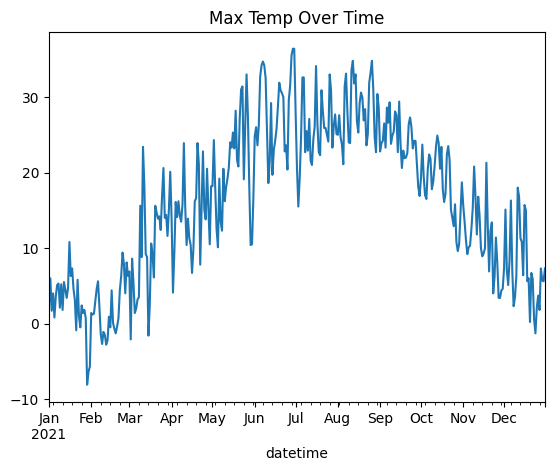

In [144]:
# Your Solution

df_weather["tempmax"].plot(title="Max Temp Over Time") #plot tempmax column with title


**Problem 7**

**Concept:** *plotting, line graphs (time series)*


**Task:**

Using `df_weather`:
* Plot the `precip` column
* Add a title
* Display the plot


<Axes: title={'center': 'Precipitation Over Time'}, xlabel='datetime'>

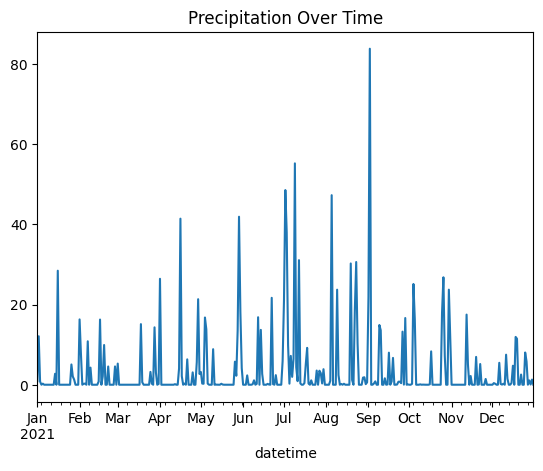

In [145]:
# Your Solution

df_weather["precip"].plot(title="Precipitation Over Time") #plot precip column with title


**Problem 8**

**Concept:** *histogram*


**Task:**

Using `df_weather`:
* Create a histogram of the `feelslike` column
* Use 25 bins
* Add a title
* Display the plot


Text(0.5, 1.0, 'Feels Like Temperature Distribution')

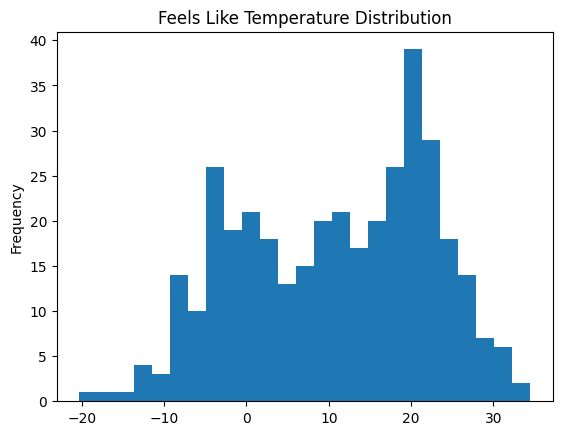

In [146]:
# Your Solution

df_weather["feelslike"].plot.hist(bins=25) #plot histogram of feelslike column with 25 bins
plt.title("Feels Like Temperature Distribution") #histogram=distribution


**Problem 9**

**Concept:** *pie chart*


**Task:**

* Print value counts of `df_weather['conditions']`
* Create a pie chart of the values
* Make sure to include labels
* Print value counts of `df_econ_data['PresidentParty']`
* Create a pie chart of the values
* Make sure to include labels

**Sample Output:**

If one of your columns contained the following values:
```
blue, black, red, green, white
```
The following could be your printed value counts:
```
blue     1
black    1
red      1
green    1
white    1
Name: color, dtype: int64
```
If another column contained the following values:
```
summer, winter, summer, spring, winter
```
The following could be your printed value counts:
```
summer    2
winter    2
spring    1
Name: season, dtype: int64
```

conditions
Partially cloudy                181
Rain, Partially cloudy           89
Rain, Overcast                   47
Snow, Rain, Overcast             18
Clear                            12
Overcast                          9
Snow, Rain, Partially cloudy      7
Snow, Overcast                    1
Snow, Partially cloudy            1
Name: count, dtype: int64


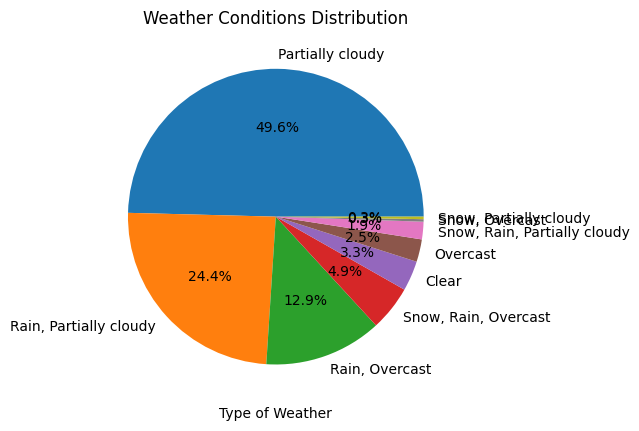

PresidentParty
Democrat      52
Republican    44
Name: count, dtype: int64


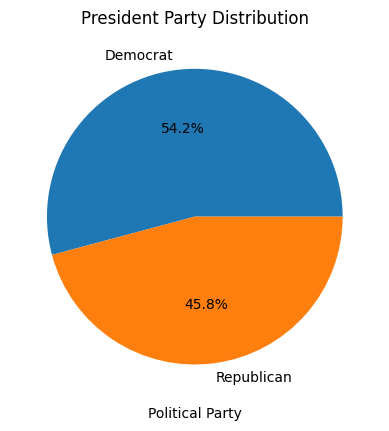

In [147]:
# Your Solution

weather_counts = df_weather["conditions"].value_counts() #use value_counts() to count occurrences of each unique value in conditions column
print(weather_counts)

weather_counts.plot.pie(autopct='%1.1f%%') #plot pie chart with percentage labels
plt.title("Weather Conditions Distribution")
plt.ylabel("") #remove y-axis label for cleaner look
plt.xlabel("Type of Weather")
plt.show()

econ_counts =df_econ_data["PresidentParty"].value_counts() #count occurrences of each unique value in PresidentParty column
print(econ_counts)

econ_counts.plot.pie(autopct='%1.1f%%') #plot pie chart with percentage labels
plt.title("President Party Distribution")
plt.ylabel('') #remove y-axis label for cleaner look
plt.xlabel("Political Party")
plt.show()

**Problem 10**

**Concept:** *creating new column data, extracting columns, plotting*


**Task:**

Using `df_weather`:
* Write a helper function to extract time (in hours) from a datetime string and convert it to decimal hours (float)
* Convert time using:

    `hours + (minutes / 60) + (seconds / 3600)`
* Create a new DataFrame with the same index as `df_weather`
* Add the following columns:
  * `sunrise` (converted to float)
  * `sunset` (converted to float)
  * `tempmin` (copied directly from `df_weather`)
* Plot all columns together using `.plot()`


**Sample Output:**

This is similar to how your new dataframe should look before plotting:

```
   start_time  end_time  price
P1       8.25     17.50     20
P2       8.50     17.75     35
P3       9.00     18.00     15
P4       9.25     18.25     60
P5       9.50     18.50     50
```

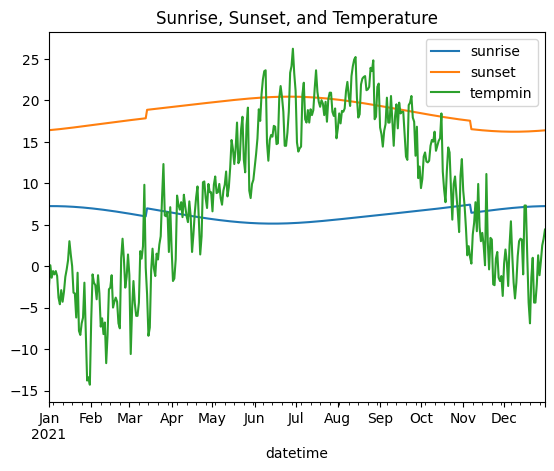

In [148]:
# Your Solution

def time_to_decimal(time_str):
    '''Converts time string HH:MM:SS to decimal hours. Handles dates as well'''
    
    time_part = time_str.split("T")[1] #split the datetime string to get the time part
    
    h, m, s = map(int, time_part.split(":")) #split the time string into hours, minutes, seconds and convert to integers
    return h + (m / 60) + (s / 3600)


df_new = pd.DataFrame(index=df_weather.index) #create new dataframe with same index as weather dataframe

df_new["sunrise"] = df_weather["sunrise"].apply(time_to_decimal) #apply the time_to_decimal function to the sunrise column and store
df_new["sunset"] = df_weather["sunset"].apply(time_to_decimal) #apply the time_to_decimal function to the sunset column and store

df_new["tempmin"] = df_weather["tempmin"] #copy tempmin column to new dataframe


df_new.plot(title="Sunrise, Sunset, and Temperature")
plt.show()



**Problem 11**

**Concept:** *descriptive statistics*


**Task:**


Using `df_stock_prices`:
* Print the first 5 rows
* Display descriptive statistics

**Important:**

Store your results in the variables below and print them. The autograder will check for these variables.
* `df_stock_prices_head`
* `df_stock_prices_descriptive_statistics`

**Sample Output:**


If the following was your dataframe:
```
   day  units_sold  revenue
1  Mon          10      200
2  Tue          15      300
3  Wed          12      240
4  Thu          18      360
5  Fri          20      400
```
The following will be your output:
```
SHOW FIRST 5 ROWS:
   day  units_sold  revenue
1  Mon          10      200
2  Tue          15      300
3  Wed          12      240
4  Thu          18      360
5  Fri          20      400

DESCRIPTIVE STATISTICS:
       units_sold     revenue
count    5.000000    5.000000
mean    15.000000  300.000000
std      4.123106   82.462113
min     10.000000  200.000000
25%     12.000000  240.000000
50%     15.000000  300.000000
75%     18.000000  360.000000
max     20.000000  400.000000
```

In [149]:
# Your Solution

df_stock_prices_head = df_stock_prices.head()
df_stock_prices_descriptive_statistics = df_stock_prices.describe()

print("SHOW FIRST 5 ROWS:")
print(df_stock_prices_head)

print("\nDESCRIPTIVE STATISTICS:")
print(df_stock_prices_descriptive_statistics)

#same as earlier problem but with stock prices instead of weather data


SHOW FIRST 5 ROWS:
                    formatted_date        date        high         low  \
date                                                                     
2025-01-02 14:30:00     2025-01-02  1735828200  591.130005  580.500000   
2025-01-03 14:30:00     2025-01-03  1735914600  592.599976  586.429993   
2025-01-06 14:30:00     2025-01-06  1736173800  599.700012  593.599976   
2025-01-07 14:30:00     2025-01-07  1736260200  597.750000  586.780029   
2025-01-08 14:30:00     2025-01-08  1736346600  590.580017  585.200012   

                           open       close    volume    adjclose  
date                                                               
2025-01-02 14:30:00  589.390015  584.640015  50204000  577.854126  
2025-01-03 14:30:00  587.530029  591.950012  37888500  585.079285  
2025-01-06 14:30:00  596.270020  595.359985  47679400  588.449707  
2025-01-07 14:30:00  597.419983  588.630005  60393100  581.797791  
2025-01-08 14:30:00  588.700012  589.489990  47304700 

**Problem 12**

**Concept:** *line graph (time series)*


**Task:**

Using `df_stock_prices`:
* Plot the `adjclose` column
* Add a title
* Display the plot


<Axes: title={'center': 'Adjusted Close Price Over Time'}, xlabel='date'>

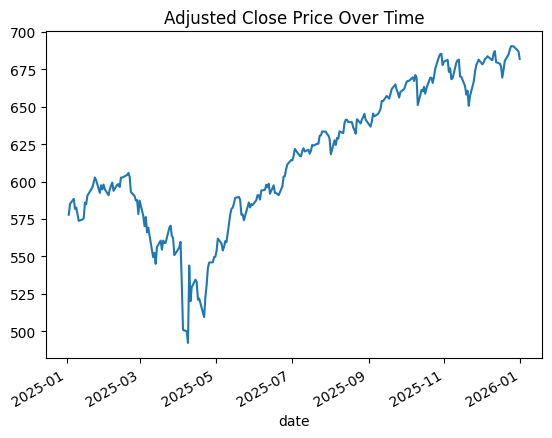

In [150]:
# Your Solution

df_stock_prices["adjclose"].plot(title="Adjusted Close Price Over Time")



**Problem 13**

**Concept:** *histogram*


**Task:**

Using `df_stock_prices`:
* Create a histogram of `adjclose`
* Use 25 bins
* Add a title
* Display the plot


Text(0.5, 1.0, 'Adjusted Close Price Distribution')

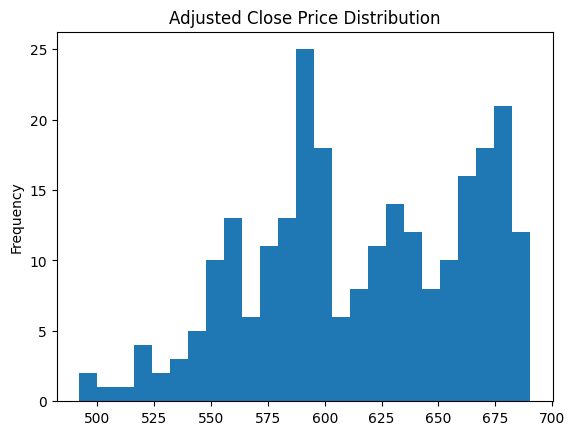

In [151]:
# Your Solution

df_stock_prices["adjclose"].plot.hist(bins=25)
plt.title("Adjusted Close Price Distribution")


**Problem 14**

**Concept:** *Creating new column.*


**Task:**

Write a function `add_range_column(df, col_a, col_b)` that:
* Creates a new column `"range"` equal to `col_a - col_b`
* Returns the updated DataFrame

**Sample Output:**

If the following was your dataframe before adding the new column:
```
   price  discount
P1     20         2
P2     35         5
P3     15         1
P4     60        10
P5     50         8
```
The following will be your output after creating the `"range"` column:
```
   price  discount  range
P1     20         2     18
P2     35         5     30
P3     15         1     14
P4     60        10     50
P5     50         8     42
```

In [152]:
# Your Solution

def add_range_column(df, col_a, col_b):
    '''Adds a 'range' column equal to col_a - col_b'''
    
    df = df.copy() #create a copy of the dataframe to avoid changing the original
    
    df["range"] = df[col_a] - df[col_b] #compute the range and store in new column
    
    return df


Test cases for problem 14

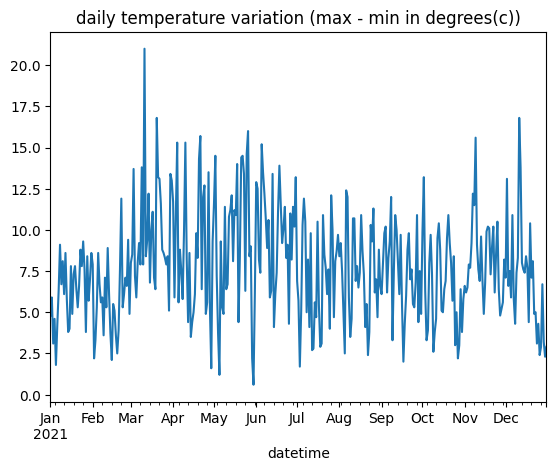

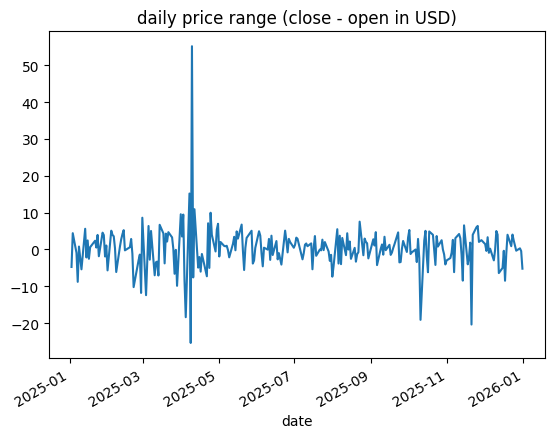

In [153]:
# test cases
df_result = add_range_column(df_weather, "tempmax", "tempmin")
df_result['range'].plot(title="daily temperature variation (max - min in degrees(c))")
plt.show()

df_result = add_range_column(df_stock_prices, "close", "open")
df_result['range'].plot(title="daily price range (close - open in USD)")
plt.show()




**Problem 15**

**Concept:** *Filtering `DataFrame` with boolean conditions*


**Task:**


Write a function `filter_rows_matching_pattern(df, column, pattern)` that:
* Returns rows where the specified column contains the given pattern
* Handles missing values
* Prints the number of matching rows

**Sample Output:**

If your selected column contained matching text values, the following could be your output:
```
Found 1 records of color containing blue.
Found 1 records of product containing hat.
Found 1 records of color containing red.
```

In [154]:
# Your Solution

def filter_rows_matching_pattern(df, column, pattern):
    '''Returns rows where column contains pattern.
    Handles missing values'''

    mask = df[column].str.contains(pattern, na=False) #create a boolean mask where True if pattern is found in the column, 
                                                        #False otherwise; na=False treats missing values as False
    result = df[mask]

    print(f"Found {len(result)} records of {column} containing {pattern}.")

    return result



Test cases for problem 15

In [155]:
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Snow")
# print(df_result.head())
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Overcast")
df_result = filter_rows_matching_pattern(df_weather, "conditions", "Clear")
# print(df_result.head())


Found 27 records of conditions containing Snow.
Found 75 records of conditions containing Overcast.
Found 12 records of conditions containing Clear.


**Problem 16**

**Concept:** *Creating new DataFrame with categorical data.*


**Task:**

Write a function `create_df_categorical(df_source, column_name)` that:
* Creates a new DataFrame with:
  * counts of each category
  * percentage of each category
* Returns the new DataFrame

**Sample Output:**

If the following was one of your categorical columns:
```
blue, black, red, green, white
```
The following will be your output:
```
       count  pct
blue       1  0.2
black      1  0.2
red        1  0.2
green      1  0.2
white      1  0.2
```
If another categorical column contained:
```
summer, winter, summer, spring, winter
```
The following will be your output:
```
        count  pct
summer      2  0.4
winter      2  0.4
spring      1  0.2
```

In [156]:
# Your Solution

def create_df_categorical(df_source, column_name):
    '''Creates a dataframe with counts and percentages of categories'''
    
    counts = df_source[column_name].value_counts() #count occurrences of each unique value in the specified column
    
    pct = counts / counts.sum() #calculate percentage by dividing counts by total count

    df_result = pd.DataFrame({
        "count": counts,
        "pct": pct               #create a new dataframe with count and percentage columns
    })
    
    return df_result



Test cases for problem 16

In [157]:
# test cases:
# 1: show categories of conditions
df_result = create_df_categorical(df_weather, "conditions")
print("CONDITIONS:")
print(df_result)
# 2: show categories of description
df_result = create_df_categorical(df_weather, "description")
print("DESCRIPTION:")
print(df_result)
# 3: show categories of UV index
df_result = create_df_categorical(df_weather, "uvindex")
print("UV INDEX")
print(df_result)

CONDITIONS:
                              count       pct
conditions                                   
Partially cloudy                181  0.495890
Rain, Partially cloudy           89  0.243836
Rain, Overcast                   47  0.128767
Snow, Rain, Overcast             18  0.049315
Clear                            12  0.032877
Overcast                          9  0.024658
Snow, Rain, Partially cloudy      7  0.019178
Snow, Overcast                    1  0.002740
Snow, Partially cloudy            1  0.002740
DESCRIPTION:
                                                    count       pct
description                                                        
Partly cloudy throughout the day.                     154  0.421918
Partly cloudy throughout the day with late afte...     21  0.057534
Becoming cloudy in the afternoon.                      20  0.054795
Cloudy skies throughout the day with a chance o...     18  0.049315
Partly cloudy throughout the day with rain.            15  0.

**Problem 17**

**Concept:** *Filtering records by category.*


**Task:**

Write a function `filter_weather(df, conditions, temp_min, temp_max)` that:
* Filters rows where:
  * conditions contain the given string
  * `tempmax` ≤ `temp_max`
  * `tempmin` ≥ `temp_min`
* Prints intermediate counts
* Returns the filtered DataFrame

**Sample Output:**

If your data matched the filtering conditions step by step, the following could be your output:
```
4 records with conditions Blue
3 records with conditions Blue and tempmax <= 50
2 records with conditions Blue and 20 <= temp <= 50
Found 2 records with conditions of Blue and temp between 20 and 50.
```

In [158]:
# Your Solution

def filter_weather(df, conditions, temp_min, temp_max):
    '''Filters weather data based on conditions and temperature range'''
    
    step1 = df[df["conditions"].str.contains(conditions, na=False)] #filter rows where conditions column contains the specified conditions; na=False treats missing values as False
    print(f"{len(step1)} records with conditions {conditions}")

    step2 = step1[step1["tempmax"] <= temp_max] #filter rows where tempmax column is less than or equal to the specified maximum temperature
    print(f"{len(step2)} records with conditions {conditions} and tempmax <= {temp_max}")

    step3 = step2[step2["tempmin"] >= temp_min] #filter rows where tempmin column is greater than or equal to the specified minimum temperature
    print(f"{len(step3)} records with conditions {conditions} and {temp_min} <= temp <= {temp_max}")

    print(f"Found {len(step3)} records with conditions of {conditions} and temp between {temp_min} and {temp_max}.")

    return step3 #return the final filtered dataframe



Test cases for problem 17

In [159]:
# looking for perfect running days:
df_result = filter_weather(df_weather, "Partially cloudy", 4, 15)
print(f"The best running days were:")
print(df_result[['tempmin', 'tempmax','conditions',]])
print()

# looking for perfect beach days:
df_result = filter_weather(df_weather, "Clear", 5, 30)
print(f"The best beach days were:")
print(df_result[['tempmin', 'tempmax','conditions',]])



278 records with conditions Partially cloudy
110 records with conditions Partially cloudy and tempmax <= 15
19 records with conditions Partially cloudy and 4 <= temp <= 15
Found 19 records with conditions of Partially cloudy and temp between 4 and 15.
The best running days were:
            tempmin  tempmax              conditions
datetime                                            
2021-03-27      6.1     14.0        Partially cloudy
2021-03-29      6.5     11.6  Rain, Partially cloudy
2021-04-05      8.5     14.1        Partially cloudy
2021-04-07      6.8     14.3        Partially cloudy
2021-04-08      7.7     13.5        Partially cloudy
2021-04-13      5.3     13.9        Partially cloudy
2021-04-14      7.8     11.3        Partially cloudy
2021-04-26      8.2     13.8        Partially cloudy
2021-05-07      8.2     13.5        Partially cloudy
2021-05-08      7.4     12.3        Partially cloudy
2021-10-24      5.6     14.0        Partially cloudy
2021-10-28      6.6      9.6   

**Problem 18**

**Concept:** *Creating DataFrame, standardizing values.*


**Task:**

Write a function `create_standardized_values(df_source, columns, row_index=None)` that:
* Creates a new DataFrame
* Standardizes values relative to a given row
* Uses the first row if none is provided
* Returns the new DataFrame

**Sample Output:**

If the following was your dataframe:
```
      high_value  low_value
2020        100        50
2021        120        55
2022        140        60
2023        160        70
2024        180        75
```
If you call the function
`create_standardized_values(df_example, ["high_value", "low_value"], 2020)`,
you should get the following as the output:
```
      high_value  low_value
2020         1.0       1.00
2021         1.2       1.10
2022         1.4       1.20
2023         1.6       1.40
2024         1.8       1.50

```

In [160]:
# Your Solution

def create_standardized_values(df_source, columns, row_index=None):
    '''Standardize values relative to a given row'''
    
    df_new = pd.DataFrame(index=df_source.index) #create new dataframe with same index as source dataframe

    if row_index is None: 
        reference = df_source.iloc[0] #if no row index is provided, use the first row as reference
    else:
        reference = df_source.loc[row_index] #if row index is provided, use the specified row as reference

    for col in columns:
        df_new[col] = df_source[col] / reference[col] #standardize each specified column by dividing by the reference value

    return df_new



Test cases for problem 18

<Axes: xlabel='Year'>

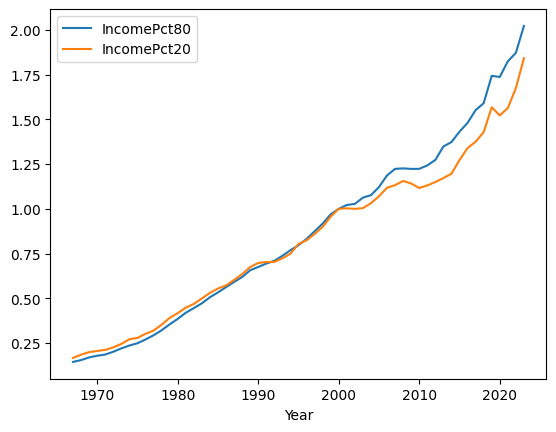

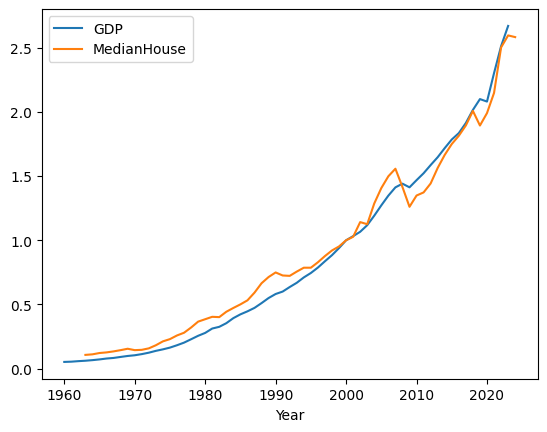

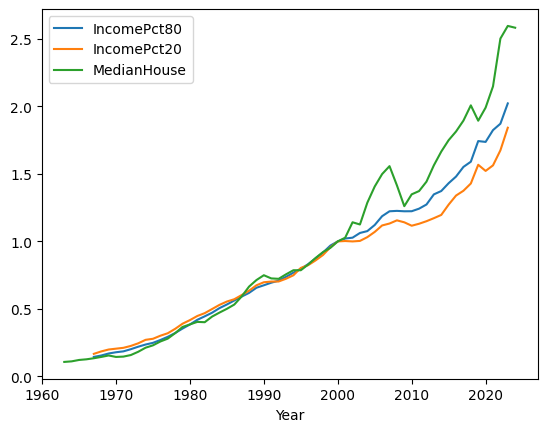

In [161]:
# test cases

# # show open/close prices relative to first item (row_index = None)
# df_result = create_standardized_values(df_stock_prices, ["open", "close"])
# df_result.plot()

# show values relative to year 2000
df_result = create_standardized_values(df_econ_data, ["IncomePct80", "IncomePct20"], 2000)
df_result.plot()

df_result = create_standardized_values(df_econ_data, ["GDP", "MedianHouse"], 2000)
df_result.plot()

df_result = create_standardized_values(df_econ_data, ["IncomePct80", "IncomePct20", "MedianHouse"], 2000)
df_result.plot()